# 📊 02 — EDA Diagnostics (Base Constructs Only)

---

## 🎯 Objective
This notebook performs **diagnostic EDA** on the baseline dataset **before feature engineering**.

We focus ONLY on the **base constructs** defined in our working document.

---

## 🧱 Base Constructs Covered

### 🗂 Context
- `content_type`, `post_format`

### 👑 Influencer Authority
- `authority_log`, `verified`, `account_age_years`

### ⚡ Persuasive Power
- `early_likes`, `early_comments`, `early_shares`, `early_engagement_velocity`, `persuasive_power_index`

### 🚀 Algorithmic Amplification
- `reach`, `impressions`, `exposure_persistence_hours`, `algorithmic_amplification_index`

### ⏳ Delayed Engagement
- `total_likes`, `total_comments`, `total_shares`

### 💼 Engagement Success
- `link_clicks`, `saves`, `profile_visits`, `click_through_rate`, `engagement_success_index`

### 🧭 Boundary
- `very_high_reach`

---

## 🚫 What we are NOT doing here
- ❌ No synthetic variables (no personas, no quality indices, no thresholds)
- ❌ No hypothesis testing / modeling
- ❌ No outlier deletion

---

## ✅ Outputs we want
- 1️⃣ Skewness & kurtosis table 
- 2️⃣ Histograms + boxplots for heavy-tail variables
- 3️⃣ Zero-inflation % for conversion actions 
- 4️⃣ Correlation heatmap (multicollinearity warning)  
- 5️⃣ Transformation recommendation table (log / keep raw / special handling)

In [5]:
# ============================================================
# 📌 Imports 
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


## 📂 Step 1 — Load baseline dataset

We load the processed baseline file produced in `01_data_loading.ipynb`.

📌 Expected path:
`../Data/processed/baseline_dataset.csv`

In [ ]:
# ============================================================
# 📌 Load dataset
# ============================================================

df = pd.read_csv("../Data/processed/baseline_dataset.csv")

print("✅ Dataset loaded")
print("Shape (rows, cols):", df.shape)
df.head(5)

## 🧱 Step 2 — Define the base constructs we are diagnosing
We explicitly list ONLY the base constructs from our working doc so we don’t accidentally pull synthetic variables.

In [7]:
# Categorical base constructs
cat_vars = ["content_type", "post_format", "verified", "very_high_reach"]

# Continuous base constructs
cont_vars = [
    "authority_log", "account_age_years",

    "early_likes", "early_comments", "early_shares",
    "early_engagement_velocity", "persuasive_power_index",

    "reach", "impressions", "exposure_persistence_hours",
    "algorithmic_amplification_index",

    "total_likes", "total_comments", "total_shares",

    "link_clicks", "saves", "profile_visits",
    "click_through_rate", "engagement_success_index"
]

# Keep a base-only df slice for this notebook
df_base = df[cat_vars + cont_vars].copy()

df_base.head(3)

,content_type,post_format,verified,very_high_reach,authority_log,account_age_years,early_likes,early_comments,early_shares,early_engagement_velocity,...,exposure_persistence_hours,algorithmic_amplification_index,total_likes,total_comments,total_shares,link_clicks,saves,profile_visits,click_through_rate,engagement_success_index
0,informational,image,0,0,10.063180,8.81,25,4,0,0.483333,...,4.98,-0.490241,25,0,2,0,2,6,0.000000,0.442417
1,promotional,video,0,0,9.760252,6.51,29,5,1,0.583333,...,7.20,-0.146071,29,6,1,0,1,1,0.000000,-0.180866
2,experiential,image,1,0,11.829552,5.12,69,17,3,1.483333,...,5.01,-0.037962,518,4,1,10,3,5,0.000496,1.986843


## 📊 Step 3 — Quick summary statistics (continuous)
This gives us quick context for scale and ranges before we look at skewness/outliers.

In [8]:
df_base[cont_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
authority_log,10000.0,1.031510e+01,0.979792,7.058758,9.638219,10.324498,10.928346,1.415273e+01
account_age_years,10000.0,6.221290e+00,3.279036,0.500000,3.510000,6.230000,9.050000,1.198000e+01
early_likes,10000.0,7.477640e+01,59.341304,0.000000,33.000000,60.000000,100.000000,5.820000e+02
early_comments,10000.0,9.232700e+00,7.999834,0.000000,4.000000,7.000000,13.000000,7.500000e+01
early_shares,10000.0,4.658800e+00,4.595138,0.000000,1.000000,3.000000,7.000000,4.400000e+01
early_engagement_velocity,10000.0,1.477798e+00,1.017520,0.033333,0.766667,1.233333,1.916667,9.816667e+00
persuasive_power_index,10000.0,5.542233e-17,0.643390,-1.113092,-0.460435,-0.129272,0.324681,4.849261e+00
reach,10000.0,2.148722e+04,110144.363531,756.000000,6044.000000,9754.000000,16734.750000,5.000000e+06
impressions,10000.0,3.536420e+04,181494.505806,1128.000000,9348.000000,15670.500000,27477.500000,9.897971e+06
exposure_persistence_hours,10000.0,6.193411e+00,0.875023,1.100000,5.640000,6.210000,6.772500,9.380000e+00


## 📐 Step 4 — Skewness & Kurtosis
This is the main “heavy-tail” diagnostic.
- Skew > 2 → strongly skewed  
- Skew > 5 → extremely skewed (log1p candidate)  
- Kurtosis >> 10 → heavy tail / extreme outliers  

In [9]:
skew_kurt = pd.DataFrame({
    "Skewness": df_base[cont_vars].skew(numeric_only=True),
    "Kurtosis": df_base[cont_vars].kurtosis(numeric_only=True)
}).sort_values("Skewness", ascending=False)

skew_kurt

,Skewness,Kurtosis
total_likes,53.259736,3634.343525
reach,32.169738,1321.557947
impressions,31.601832,1320.744204
profile_visits,18.336686,713.590418
link_clicks,12.318083,244.205459
click_through_rate,7.162739,90.766415
saves,5.884623,60.993629
total_shares,2.151834,7.560537
total_comments,1.967878,6.465044
early_likes,1.912070,6.196251


## 📊 Step 5 — Histograms (key heavy-tail variables)
We don’t plot every column — only the ones most likely to be viral / conversion heavy-tailed.

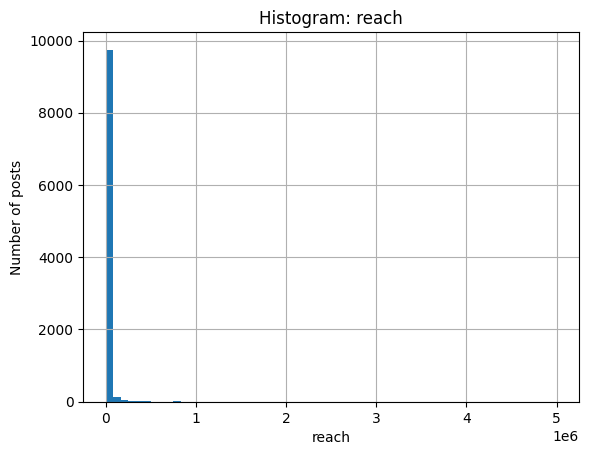

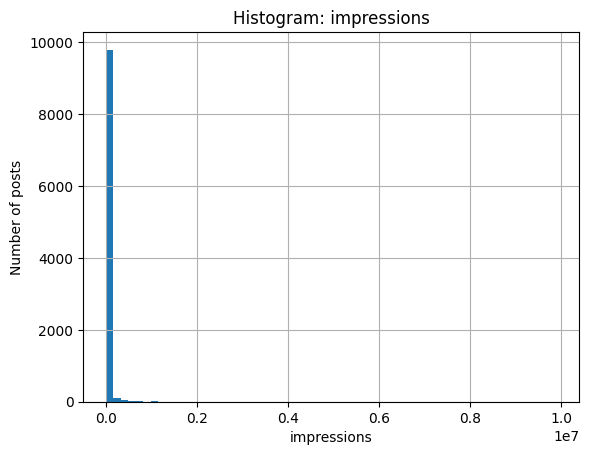

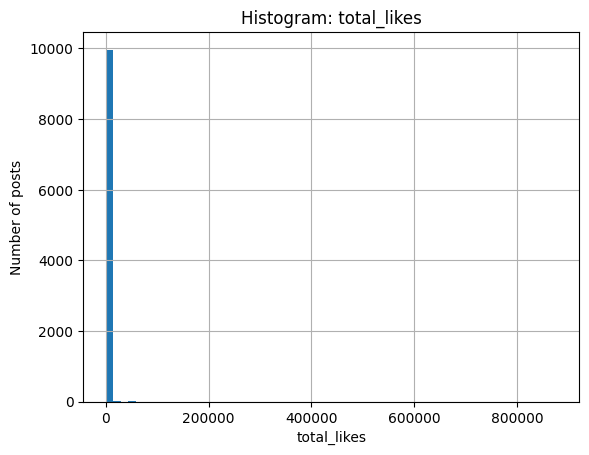

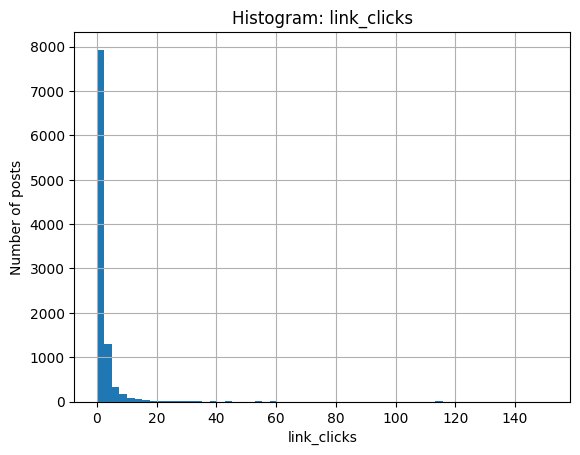

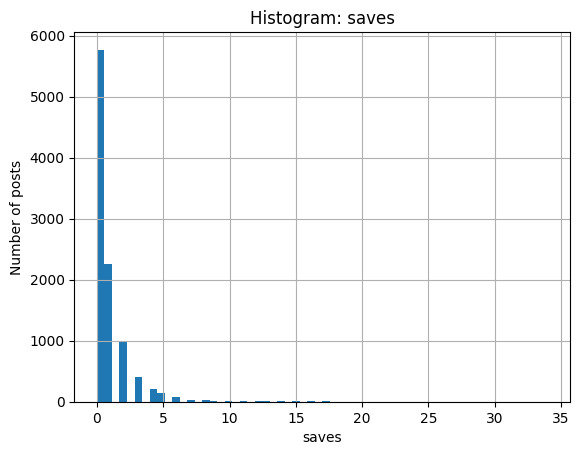

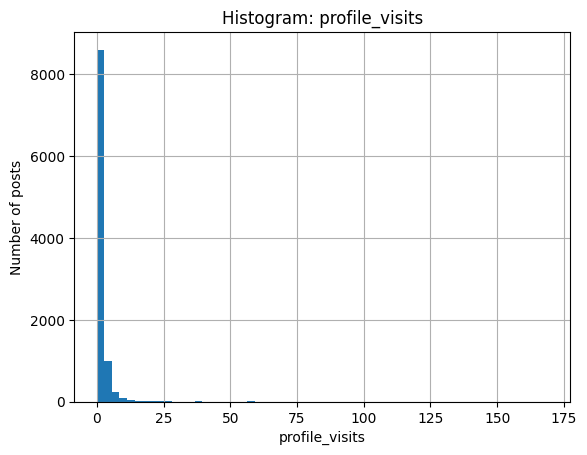

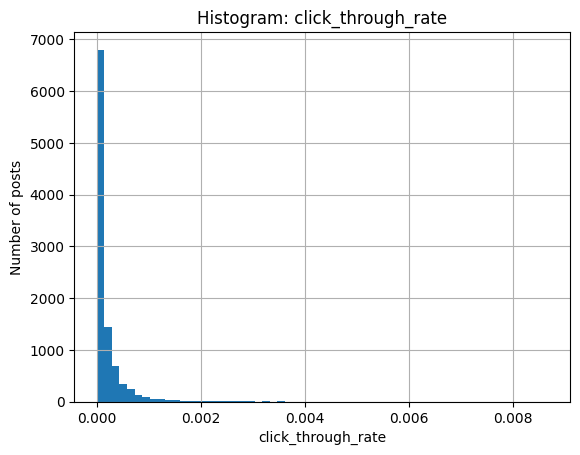

In [10]:
def plot_hist(col, bins=60):
    plt.figure()
    df_base[col].dropna().hist(bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Number of posts")
    plt.show()

hist_vars = [
    "reach", "impressions", "total_likes",
    "link_clicks", "saves", "profile_visits",
    "click_through_rate"
]

for col in hist_vars:
    plot_hist(col)

## 📦 Step 6 — Boxplots (outlier visibility)
This shows the “tail dominance” clearly.
Reminder: we are not deleting outliers — only diagnosing.


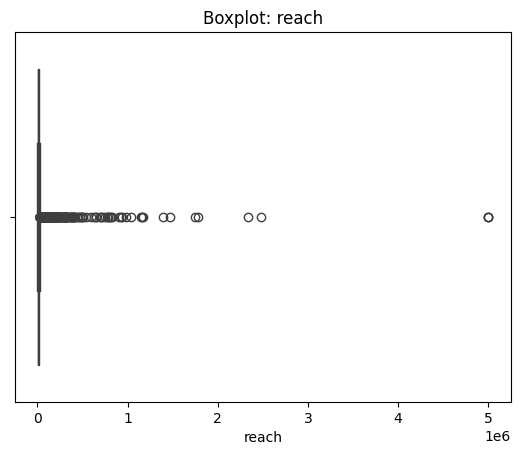

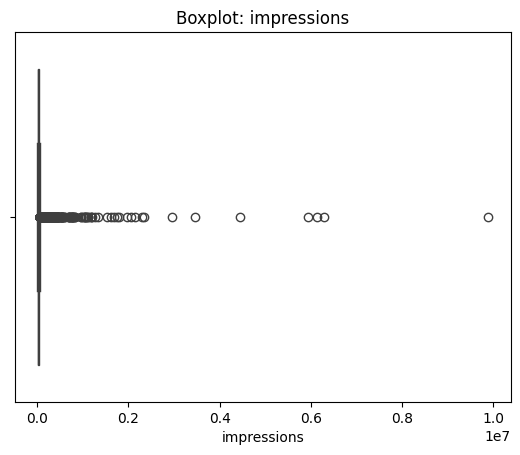

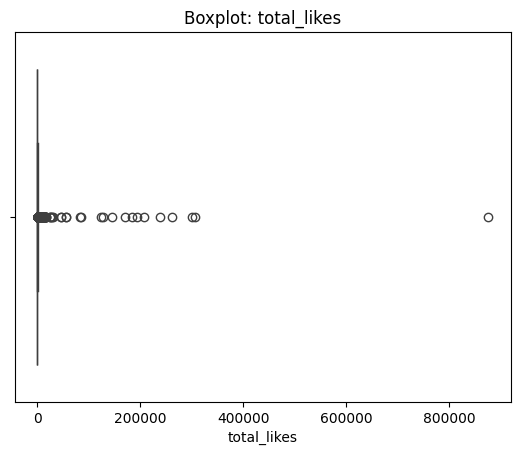

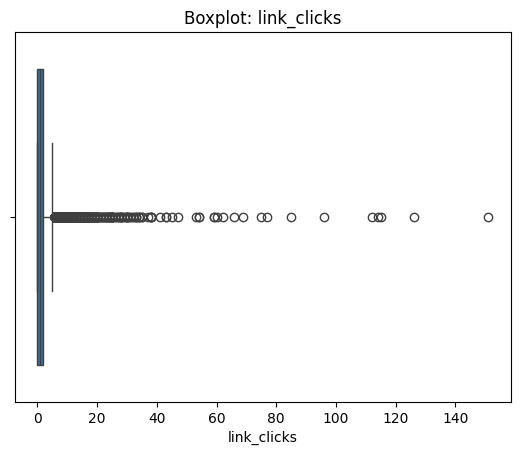

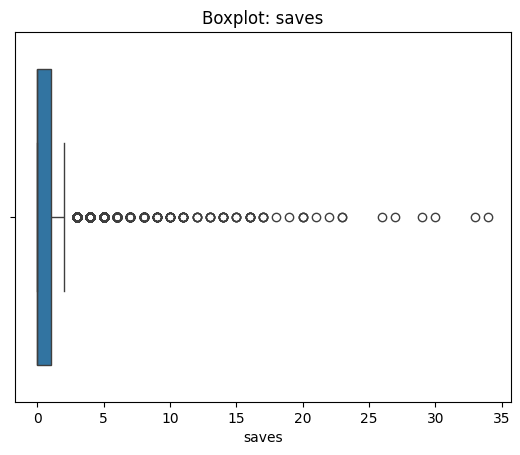

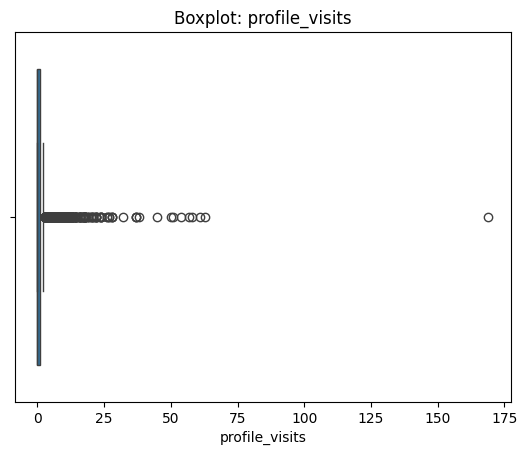

In [11]:
def plot_box(col):
    plt.figure()
    sns.boxplot(x=df_base[col].dropna())
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

box_vars = ["reach", "impressions", "total_likes", "link_clicks", "saves", "profile_visits"]

for col in box_vars:
    plot_box(col)